# Image Preprocessing Pipeline for Microscopy/Tomography Images

This notebook demonstrates a basic preprocessing workflow for image-based machine learning.

The pipeline:
1. Scores image sharpness using the variance of the Laplacian
2. Selects the sharpest frame from each rotation-angle window
3. Generates synthetic blurred images for supervised ML training
4. Extracts aligned sharp/blurry patches for training data

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

# If notebook is opened from the notebooks folder, go back to main project folder
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

DATA_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\sofii\Documents\bug-skin-image-preprocessing


## 1. Sharpness detection

We compute a sharpness score for each image using the variance of the Laplacian.  
Higher values usually mean sharper edges and less blur.

Found 4 images. Scoring sharpness...
Done scoring 4 images.

Selected 1 diverse frames (1 per 10 degree window)
Copying to:
  c:\Users\sofii\Documents\bug-skin-image-preprocessing\data\sharpest_frames

  Window       Score    Angle  Filename
──────────────────────────────────────────────────────────────────────
     340°       170.9      346°  004_score75097.2_angle_346.png

Total ground truth candidates: 1 images


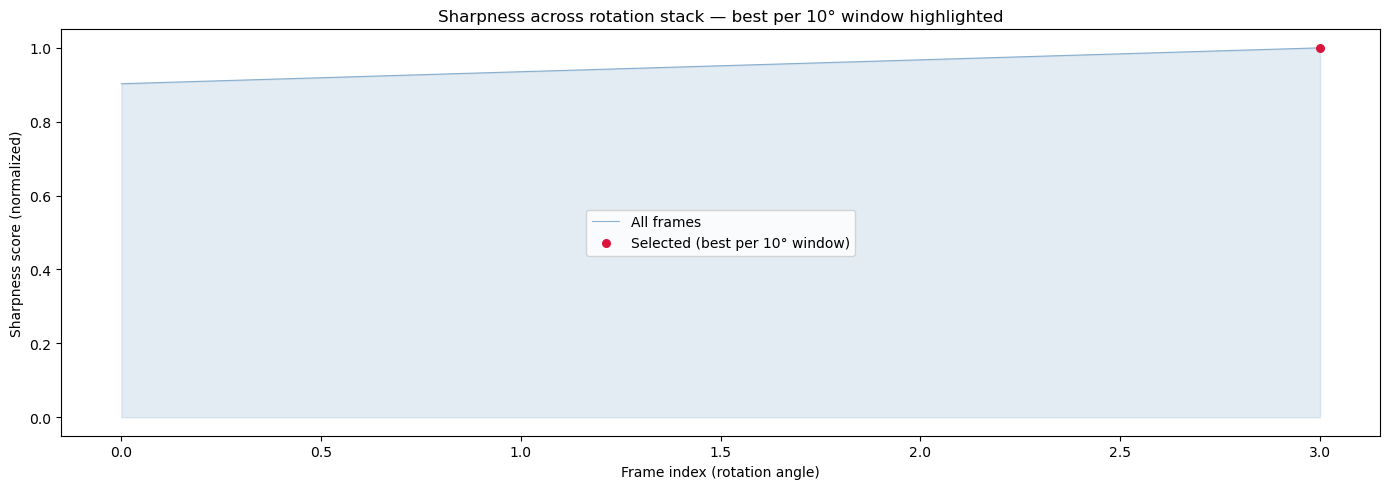


Plot saved to:
  c:\Users\sofii\Documents\bug-skin-image-preprocessing\outputs\sharpness_curve.png


In [3]:
"""
Sharpness Detection for Microscopy Images — Best Frame Per Angle Window
------------------------------------------------------------------------
Scans a folder of TIFF images, scores each by sharpness (Laplacian variance),
then picks the BEST frame per angle window (e.g. every 10 degrees).
This ensures diverse ground truth across all viewing angles.

"""

import re
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import cv2

# ─────────────────────────────────────────────
# CONFIG — edit these
# ─────────────────────────────────────────────
INPUT_FOLDER = PROJECT_ROOT / "data" / "sample_png"
OUTPUT_FOLDER = PROJECT_ROOT / "data" / "sharpest_frames"
PLOT_OUTPUT = PROJECT_ROOT / "outputs" / "sharpness_curve.png"
ANGLE_WINDOW  = 10      # degrees per window (10 = ~36 images for 360° rotation)
                        # use 5 for more images, 20 for fewer
EXTENSIONS    = ('.tif', '.tiff', '.png')

# How angle is encoded in your filenames — edit if your naming is different
# Matches patterns like: frame_343.tif / img_0343.tif / angle343.tif / 00343.tif
# Script will try multiple patterns automatically
# ─────────────────────────────────────────────


def laplacian_variance(img_gray):
    """Higher = sharper."""
    return cv2.Laplacian(img_gray, cv2.CV_64F).var()


def extract_angle(filename):
    """
    Try to extract a rotation angle / frame number from the filename.
    Tries several common naming patterns. Returns an int or None.
    """
    name = Path(filename).stem

    patterns = [
        r'angle[_\-]?(\d+)',       # angle_343, angle343
        r'frame[_\-]?(\d+)',       # frame_343
        r'img[_\-]?(\d+)',         # img_343
        r'[_\-](\d{3,4})$',        # anything ending in _343 or _0343
        r'^(\d{3,4})',              # starts with 343 or 0343
    ]

    for p in patterns:
        m = re.search(p, name, re.IGNORECASE)
        if m:
            return int(m.group(1))

    return None


def score_images(folder):
    folder = Path(folder)
    files = sorted([f for f in folder.iterdir() if f.suffix.lower() in EXTENSIONS])

    if not files:
        print(f"No TIFF files found in {folder}")
        return []

    print(f"Found {len(files)} images. Scoring sharpness...")

    scores = []
    no_angle_count = 0

    for i, f in enumerate(files):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"  Could not read: {f.name}")
            continue

        score = laplacian_variance(img)
        angle = extract_angle(f.name)

        if angle is None:
            no_angle_count += 1

        scores.append((f, score, angle))

        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(files)}...")

    print(f"Done scoring {len(scores)} images.")

    if no_angle_count > 0:
        print(f"  Warning: could not extract angle from {no_angle_count} filenames.")
        print(f"  These will be grouped by frame index instead.")

    return scores


def assign_windows(scores, window_size):
    """
    Group images into angle windows. 
    If angle can't be extracted from filename, use frame index instead.
    """
    windowed = defaultdict(list)

    for i, (f, score, angle) in enumerate(scores):
        key = angle if angle is not None else i
        window = (key // window_size) * window_size  # e.g. 343 -> 340
        windowed[window].append((f, score, angle))

    return windowed


def save_best_per_window(windowed, output_folder):
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    best_frames = []
    for window_start in sorted(windowed.keys()):
        group = windowed[window_start]
        best = max(group, key=lambda x: x[1])  # highest sharpness score
        best_frames.append((window_start, best[0], best[1], best[2]))

    print(f"\nSelected {len(best_frames)} diverse frames (1 per {ANGLE_WINDOW} degree window)")
    print(f"Copying to:\n  {output_folder}\n")

    print(f"{'Window':>8}  {'Score':>10}  {'Angle':>7}  {'Filename'}")
    print("─" * 70)

    for rank, (window, f, score, angle) in enumerate(best_frames, 1):
        angle_str = str(angle) if angle is not None else "?"
        dest = output_folder / f"{rank:03d}_window{window:03d}_score{score:.0f}_angle{angle_str}_{f.name}"
        shutil.copy2(f, dest)
        print(f"{window:>8}°  {score:>10.1f}  {angle_str:>7}°  {f.name}")

    print(f"\nTotal ground truth candidates: {len(best_frames)} images")
    return best_frames


def plot_sharpness_curve(scores, best_frames, plot_output, window_size):
    indices = list(range(len(scores)))
    values  = np.array([s for _, s, _ in scores])
    values_norm = values / values.max()

    # Mark selected frames
    selected_indices = []
    selected_values  = []
    score_map = {str(f): (i, s) for i, (f, s, _) in enumerate(scores)}
    for _, f, score, _ in best_frames:
        if str(f) in score_map:
            idx, s = score_map[str(f)]
            selected_indices.append(idx)
            selected_values.append(s / values.max())

    plt.figure(figsize=(14, 5))
    plt.plot(indices, values_norm, linewidth=0.8, color='steelblue', alpha=0.6, label='All frames')
    plt.fill_between(indices, values_norm, alpha=0.15, color='steelblue')
    plt.scatter(selected_indices, selected_values, color='crimson', s=30, zorder=5,
                label=f'Selected (best per {window_size}° window)')
    plt.xlabel("Frame index (rotation angle)")
    plt.ylabel("Sharpness score (normalized)")
    plt.title(f"Sharpness across rotation stack — best per {window_size}° window highlighted")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_output, dpi=150)
    plt.show()
    print(f"\nPlot saved to:\n  {plot_output}")


if __name__ == "__main__":
    scores = score_images(INPUT_FOLDER)

    if scores:
        windowed   = assign_windows(scores, ANGLE_WINDOW)
        best_frames = save_best_per_window(windowed, OUTPUT_FOLDER)
        plot_sharpness_curve(scores, best_frames, PLOT_OUTPUT, ANGLE_WINDOW)

The selected frames are saved in `data/sharpest_frames/`.
The sharpness plot is saved in `outputs/sharpness_curve.png`.

## 2. Synthetic blur generation

To create training pairs for image restoration, we treat selected sharp frames as ground truth and apply Gaussian blur to generate blurry inputs.

In [4]:
"""
Blur Simulation — Create Training Pairs
-----------------------------------------
Takes your curated ground truth images and generates multiple
blurry versions of each, simulating realistic defocus blur.

Output structure:
    training_pairs/
        sharp/    ← copies of your ground truth (the target)
        blurry/   ← synthetically blurred versions (the input)

Each sharp image gets N blurry versions at different blur strengths,
giving you ~200-350 training pairs from 35 ground truth images.

"""

import numpy as np
import shutil
from pathlib import Path
from skimage import io, img_as_float, img_as_uint
from skimage.filters import gaussian
import cv2
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_FOLDER = PROJECT_ROOT / "data" / "sharpest_frames"
OUTPUT_FOLDER = PROJECT_ROOT / "data" / "training_pairs"
SINGLE_IMAGE  = ""  # set to a filename to test one image, or "" to process all

# Blur strengths to simulate (Gaussian sigma values)
# These correspond to mild → heavy defocus
# Adjust based on how blurry your worst images look
BLUR_SIGMAS   = [1.5, 2.5, 4.0, 6.0, 8.0, 11.0, 15.0]
# That's 7 versions per image × 35 images = 245 pairs

# Add a small amount of noise to each blurry version (realistic)
# Set to 0 to disable
NOISE_STD     = 0.01   # std of Gaussian noise (0.0 - 0.05 range)

EXTENSIONS    = ('.tif', '.tiff', '.png', '.jpg')
# ─────────────────────────────────────────────


def add_noise(img_float, std):
    if std <= 0:
        return img_float
    noise = np.random.normal(0, std, img_float.shape)
    return np.clip(img_float + noise, 0, 1)


def simulate_defocus_blur(img_float, sigma):
    """
    Simulate defocus blur using a Gaussian kernel.
    This matches the smooth/soft out-of-focus look in your images.
    """
    blurred = gaussian(img_float, sigma=sigma)
    return np.clip(blurred, 0, 1)


def process(input_folder, output_folder):
    input_folder  = Path(input_folder)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    if SINGLE_IMAGE:
        files = [input_folder / SINGLE_IMAGE]
        print(f"Test mode: single image only")
    else:
        files = sorted([f for f in input_folder.iterdir()
                        if f.suffix.lower() in EXTENSIONS])

    if not files:
        print(f"No images found in {input_folder}")
        return

    total_pairs = len(files) * len(BLUR_SIGMAS)
    print(f"Found {len(files)} ground truth images")
    print(f"Generating {len(BLUR_SIGMAS)} blurry versions each → {total_pairs} total pairs")
    print(f"Blur sigmas: {BLUR_SIGMAS}\n")

    pair_count = 0
    for i, f in enumerate(files, 1):
        # Load as float grayscale
        img_raw = io.imread(str(f))
        if img_raw.ndim == 3:
            img_raw = np.mean(img_raw[:, :, :3], axis=2)
        img_float = np.clip(img_as_float(img_raw).astype(np.float64), 0, 1)

        print(f"[{i:02d}/{len(files)}] {f.name}")

        # Each image gets its own subfolder
        stem = f.stem
        pair_folder = output_folder / stem
        pair_folder.mkdir(parents=True, exist_ok=True)

        # Save sharp image once
        io.imsave(str(pair_folder / "sharp.tiff"), img_as_uint(img_float))

        for sigma in BLUR_SIGMAS:
            # Blurry: apply defocus blur + noise
            blurry = simulate_defocus_blur(img_float, sigma)
            blurry = add_noise(blurry, NOISE_STD)
            blurry = np.clip(blurry, 0, 1).astype(np.float64)
            io.imsave(str(pair_folder / f"blurry_sigma{sigma:.1f}.tiff"), img_as_uint(blurry))
            pair_count += 1

    print(f"\nDone! Generated {pair_count} training pairs across {len(files)} folders.")
    print(f"Output → {output_folder}")
    print(f"\nEach subfolder contains:")
    print(f"  sharp.tiff              ← ground truth")
    print(f"  blurry_sigma1.5.tiff    ← mildly blurred")
    print(f"  blurry_sigma15.0.tiff   ← heavily blurred")


if __name__ == "__main__":
    np.random.seed(42)
    process(INPUT_FOLDER, OUTPUT_FOLDER)

Found 1 ground truth images
Generating 7 blurry versions each → 7 total pairs
Blur sigmas: [1.5, 2.5, 4.0, 6.0, 8.0, 11.0, 15.0]

[01/1] 001_window340_score171_angle346_004_score75097.2_angle_346.png

Done! Generated 7 training pairs across 1 folders.
Output → c:\Users\sofii\Documents\bug-skin-image-preprocessing\data\training_pairs

Each subfolder contains:
  sharp.tiff              ← ground truth
  blurry_sigma1.5.tiff    ← mildly blurred
  blurry_sigma15.0.tiff   ← heavily blurred


The generated training pairs are saved in `data/training_pairs/`.
Each folder contains one sharp image and several blurred versions.

## 3. Patch extraction

Large microscopy images are cropped into smaller aligned patches.  
Each sharp patch and blurry patch are cropped at the same position so they can be used as supervised ML training pairs.

In [5]:
"""
Patch Extraction for Training
-------------------------------
Crops your full-size training pairs (4096x3000) into 256x256 patches.
Each sharp/blurry pair is cropped at the SAME positions so they stay aligned.

Only saves patches that contain actual sample content (not blank background).

Output structure:
    training_patches/
        001_window000_.../
            patch_000_sharp.tiff
            patch_000_blurry_sigma1.5.tiff
            patch_001_sharp.tiff
            patch_001_blurry_sigma1.5.tiff
            
"""

import numpy as np
from pathlib import Path
from skimage import io, img_as_float, img_as_uint
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_FOLDER = PROJECT_ROOT / "data" / "training_pairs"
OUTPUT_FOLDER = PROJECT_ROOT / "data" / "training_patches"

PATCH_SIZE     = 256     # pixels — standard for most deblurring models
STRIDE         = 128     # step between patches (128 = 50% overlap, more data)
                         # set equal to PATCH_SIZE for no overlap (fewer patches)

# Minimum fraction of patch that must be sample (not bright background)
# Filters out patches that are mostly white aperture with no useful content
MIN_CONTENT    = 0.5     # at least 50% of patch must be non-background

BACKGROUND_THRESHOLD = 0.75  # pixels brighter than this are background (tightened)
MIN_BRIGHTNESS = 0.15        # patches below this mean brightness are too dark

# Test mode — set to True to only process the first image folder
TEST_MODE      = False
# ─────────────────────────────────────────────


def has_enough_content(patch, threshold, min_content):
    """Check if patch has enough sample pixels — not too bright (background) and not too dark (black corners)."""
    if patch.mean() < MIN_BRIGHTNESS:
        return False  # pure black corner patch
    background_pixels = (patch > threshold).sum()
    total_pixels = patch.size
    content_fraction = 1.0 - (background_pixels / total_pixels)
    return content_fraction >= min_content


def extract_patches(img, patch_size, stride):
    """Extract all patch positions from an image."""
    h, w = img.shape
    positions = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            positions.append((y, x))
    return positions


def process(input_folder, output_folder):
    input_folder  = Path(input_folder)
    output_folder = Path(output_folder)

    # Find all per-image subfolders
    subfolders = sorted([f for f in input_folder.iterdir() if f.is_dir()])

    if TEST_MODE:
        subfolders = subfolders[:1]
        print("TEST MODE: processing first folder only")

    if not subfolders:
        print(f"No subfolders found in {input_folder}")
        return

    print(f"Found {len(subfolders)} image folders")
    print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}  Stride: {STRIDE}  Min content: {MIN_CONTENT*100:.0f}%\n")

    total_patches = 0

    for i, subfolder in enumerate(subfolders, 1):
        sharp_path = subfolder / "sharp.tiff"
        blurry_paths = sorted(subfolder.glob("blurry_sigma*.tiff"))

        if not sharp_path.exists() or not blurry_paths:
            print(f"  Skipping {subfolder.name} — missing files")
            continue

        # Load sharp image
        sharp_raw = io.imread(str(sharp_path))
        if sharp_raw.ndim == 3:
            sharp_raw = np.mean(sharp_raw[:, :, :3], axis=2)
        sharp = np.clip(img_as_float(sharp_raw).astype(np.float64), 0, 1)

        # Load all blurry versions
        blurry_imgs = {}
        for bp in blurry_paths:
            blurry_raw = io.imread(str(bp))
            if blurry_raw.ndim == 3:
                blurry_raw = np.mean(blurry_raw[:, :, :3], axis=2)
            blurry_imgs[bp.stem] = np.clip(img_as_float(blurry_raw).astype(np.float64), 0, 1)

        # Get patch positions from sharp image
        positions = extract_patches(sharp, PATCH_SIZE, STRIDE)

        # Filter positions by content
        valid_positions = [
            (y, x) for y, x in positions
            if has_enough_content(
                sharp[y:y+PATCH_SIZE, x:x+PATCH_SIZE],
                BACKGROUND_THRESHOLD,
                MIN_CONTENT
            )
        ]

        print(f"[{i:02d}/{len(subfolders)}] {subfolder.name}")
        print(f"  {len(positions)} total patches → {len(valid_positions)} with enough content")

        if not valid_positions:
            print(f"  Warning: no valid patches found, skipping")
            continue

        # Create output subfolder
        sharp_out  = output_folder / subfolder.name / "sharp"
        blurry_out = output_folder / subfolder.name / "blurry"
        sharp_out.mkdir(parents=True, exist_ok=True)
        blurry_out.mkdir(parents=True, exist_ok=True)

        # Save patches
        patch_count = 0
        for y, x in valid_positions:
            # Sharp patch
            sharp_patch = sharp[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            io.imsave(
                str(sharp_out / f"patch_{patch_count:03d}.tiff"),
                img_as_uint(sharp_patch)
            )

            # Blurry patches (one per sigma)
            for name, blurry in blurry_imgs.items():
                blurry_patch = blurry[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                io.imsave(
                    str(blurry_out / f"patch_{patch_count:03d}_{name}.tiff"),
                    img_as_uint(blurry_patch)
                )

            patch_count += 1

        total_patches += patch_count
        print(f"  Saved {patch_count} patch sets\n")

    print(f"{'─'*50}")
    print(f"Done! Total patch sets: {total_patches}")
    print(f"Total individual files: {total_patches * (1 + len(blurry_imgs))}")
    print(f"Output → {output_folder}")
    print(f"\nNext step: use these patches as input/target pairs for an image restoration model.")


if __name__ == "__main__":
    process(INPUT_FOLDER, OUTPUT_FOLDER)

Found 1 image folders
Patch size: 256x256  Stride: 128  Min content: 50%

[01/1] 001_window340_score171_angle346_004_score75097.2_angle_346
  9 total patches → 4 with enough content
  Saved 4 patch sets

──────────────────────────────────────────────────
Done! Total patch sets: 4
Total individual files: 32
Output → c:\Users\sofii\Documents\bug-skin-image-preprocessing\data\training_patches

Next step: use these patches as input/target pairs for an image restoration model.


The extracted training patches are saved in `data/training_patches/`.
Each sharp patch has corresponding blurry patches cropped at the same location.